# CS156 Session 9: Metrics and Cross-Validation

Train/test split, ROC-AUC for two classifiers, and tuning hyperparameters on a validation set.

Note: `random_state=0` is set where the original workbook had no seed, so the numbers below are reproducible. They will differ from the values in my submitted workbook run. My written answers are in `session9_workbook.md` and refer to that original run.

## Assignment prep questions

Describe the dataset you plan to analyze for Assignment 1, patterns you might find, how the analysis might go wrong, and which measures would show that something weird happened.

*Add your answer here. It was not in the workbook text I had.*

## Dataset: two concentric circles

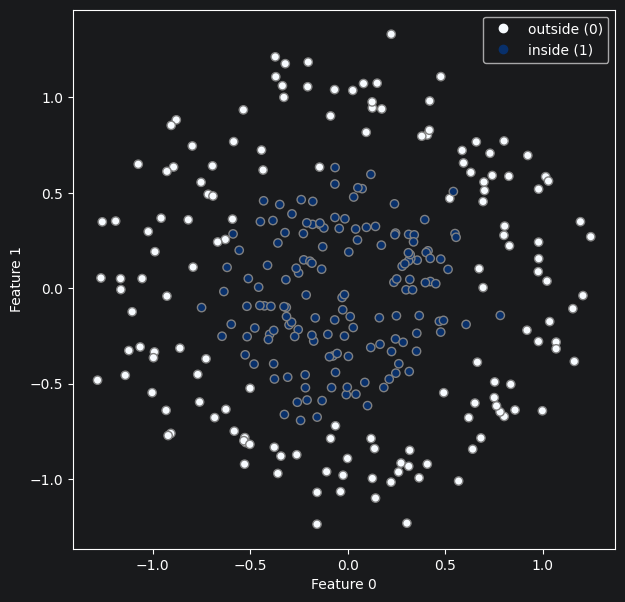

In [1]:
from sklearn import datasets, linear_model, metrics, model_selection, svm
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np

NUM_DATAPOINTS = 300

x_data, y_data = datasets.make_circles(n_samples=NUM_DATAPOINTS, noise=0.15, factor=.4, random_state=0)

fig, ax = plt.subplots(figsize=(7, 7))
scatter = ax.scatter(
    x_data[:, 0],
    x_data[:, 1],
    c=y_data,
    edgecolors="grey",
    cmap="Blues",
    vmin=0,
    vmax=1,
)
ax.set_xlabel("Feature 0")
ax.set_ylabel("Feature 1")
ax.legend(handles=scatter.legend_elements()[0], labels=["outside (0)", "inside (1)"])
plt.show()

## Q1: 80/20 train/test split

A random split: each point is randomly assigned to train or test.

In [2]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(
    x_data, y_data, test_size=0.2, train_size=0.8, random_state=0)

## Fit a logistic regression and an SVM

The SVM is treated as a black box here: a model that can learn a non-linear decision boundary. The printed numbers are test accuracy at a 0.5 threshold.

In [3]:
linear_clf = linear_model.LogisticRegression()
linear_clf.fit(x_train, y_train)

svm_clf = svm.SVC(gamma=2, C=1, probability=True)
svm_clf.fit(x_train, y_train)

print(linear_clf.score(x_test, y_test), svm_clf.score(x_test, y_test))

0.38333333333333336 0.9666666666666667


### Plotting helper for the decision surfaces

In [4]:
def plot_decision_surface(clf, xs, ys, ax, title):
    xs = np.linspace(xs[0], xs[1], 100)
    ys = np.linspace(ys[0], ys[1], 100)
    x_mesh, y_mesh = np.meshgrid(xs, ys)

    vis_x = np.stack((x_mesh, y_mesh), axis=2).reshape(-1, 2)
    vis_y = clf.predict_proba(vis_x)[:, 1].reshape(100, 100)

    contour = ax.contourf(
        x_mesh, y_mesh, vis_y, levels=np.linspace(0, 1, 33), cmap="Blues"
    )

    contour.set_clim(0, 1)
    ax.scatter(
        x_data[:, 0],
        x_data[:, 1],
        c=y_data,
        edgecolors="grey",
        cmap="Blues",
        vmin=0,
        vmax=1,
    )
    ax.set_title(title)
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")

The logistic regression has a linear boundary, so it struggles on concentric circles.

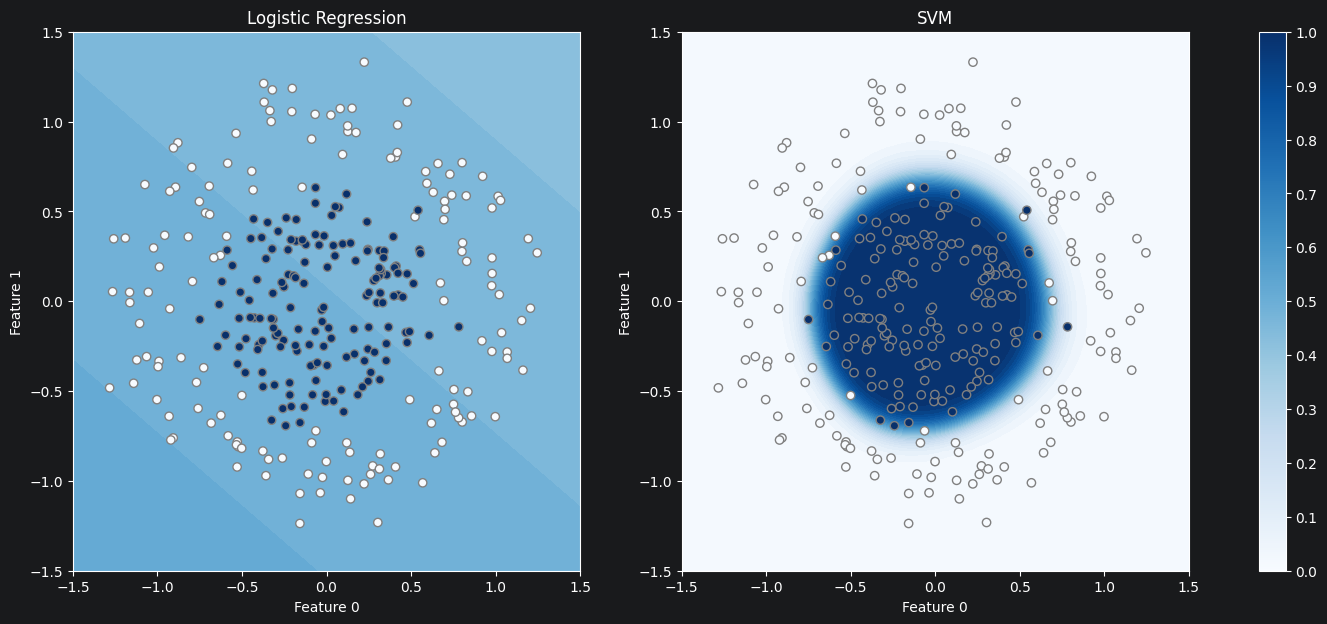

In [5]:
fig, ax = plt.subplots(ncols=2, figsize=(18, 7))
fig.colorbar(cm.ScalarMappable(cmap="Blues"), ticks=np.linspace(0, 1, 11), ax=ax)
plot_decision_surface(linear_clf, (-1.5, 1.5), (-1.5, 1.5), ax[0], "Logistic Regression")
plot_decision_surface(svm_clf, (-1.5, 1.5), (-1.5, 1.5), ax[1], "SVM")
plt.show()

## ROC curves

Accuracy above used one threshold (0.5). ROC-AUC measures performance across all thresholds.

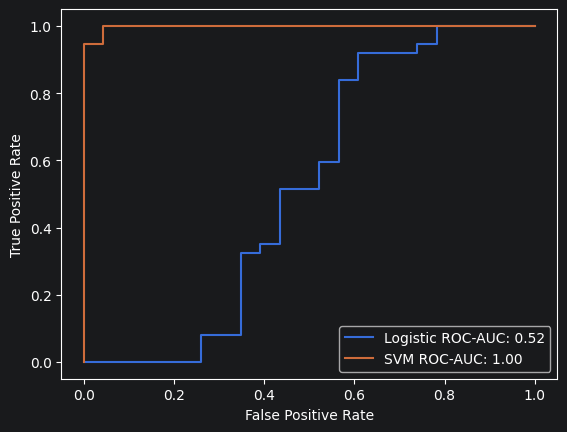

In [6]:
linear_preds = linear_clf.predict_proba(x_test)[:, 1]
svm_preds = svm_clf.predict_proba(x_test)[:, 1]

linear_curve = metrics.roc_curve(y_test, linear_preds)
svm_curve = metrics.roc_curve(y_test, svm_preds)

plt.plot(linear_curve[0], linear_curve[1], label="Logistic ROC-AUC: %.2f" % metrics.roc_auc_score(y_test, linear_preds))
plt.plot(svm_curve[0], svm_curve[1], label="SVM ROC-AUC: %.2f" % metrics.roc_auc_score(y_test, svm_preds))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Tuning C and gamma on a validation set

The test set is locked away. The training data is split again 80/20 into train and validation, and a grid search over `C` and `gamma` is scored by validation ROC-AUC. The winner is refit on all training data and evaluated on the test set once.

The re-split below replaces the earlier split with one that has the same seed, so the test set is the same as above.

In [7]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(
    x_data, y_data, test_size=0.2, train_size=0.8, random_state=0)

# Split the training data again: 80/20 -> train / validation
x_tr, x_val, y_tr, y_val = model_selection.train_test_split(
    x_train, y_train, test_size=0.2, train_size=0.8, random_state=0)

# Grid search over both hyperparameters
C_values = [0.01, 0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

best_auc, best_params = -np.inf, None
for C in C_values:
    for gamma in gamma_values:
        model = svm.SVC(kernel="rbf", C=C, gamma=gamma)
        model.fit(x_tr, y_tr)                              # parameters learned on train only
        scores = model.decision_function(x_val)            # scores, not hard labels
        auc = metrics.roc_auc_score(y_val, scores)         # evaluated on validation
        if auc > best_auc:                                 # strict ">" keeps the first pair to reach the max
            best_auc, best_params = auc, (C, gamma)

print("Best (C, gamma):", best_params, "validation AUC:", best_auc)

# Refit with the chosen hyperparameters on all training data, then test ONCE
C_best, gamma_best = best_params
final_model = svm.SVC(kernel="rbf", C=C_best, gamma=gamma_best)
final_model.fit(x_train, y_train)
test_auc = metrics.roc_auc_score(y_test, final_model.decision_function(x_test))
print("Test ROC-AUC:", test_auc)

Best (C, gamma): (0.01, 1) validation AUC: 0.9982517482517483
Test ROC-AUC: 0.9976498237367802
